# Exercícios — Regularização

**Tema:** Aprendizado Supervisionado › Regularização

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(808)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Padronizar antes de regularizar

Gere duas features: `x1` em escala 0-1 e `x2` em escala 0-10.000, ambas com
o MESMO efeito real no alvo (coeficiente 2 nas unidades originais, depois
de padronizar as duas para gerar y). Ajuste um Ridge SEM padronizar as
features primeiro, e outro COM padronização. Compare os coeficientes.

In [2]:
# --- sua resposta ---

### Gabarito 1

In [3]:
n = 500
x1 = rng.uniform(0, 1, n)
x2 = rng.uniform(0, 10000, n)
x1_z, x2_z = StandardScaler().fit_transform(np.column_stack([x1, x2])).T
y = 2 * x1_z + 2 * x2_z + rng.normal(0, 1, n)

X_bruto = np.column_stack([x1, x2])
X_padronizado = StandardScaler().fit_transform(X_bruto)

ridge_bruto = Ridge(alpha=1.0).fit(X_bruto, y)
ridge_padronizado = Ridge(alpha=1.0).fit(X_padronizado, y)

print(f"coeficientes SEM padronizar: {ridge_bruto.coef_}")
print(f"coeficientes COM padronizar: {ridge_padronizado.coef_}")

coeficientes SEM padronizar: [6.75734374e+00 7.06591516e-04]
coeficientes COM padronizar: [1.99723678 1.9929162 ]


**Resposta esperada:** sem padronizar, os coeficientes ficam em escalas
completamente diferentes (um multiplicado por algo da ordem de 1, outro por
algo da ordem de 0,0002) só por causa da unidade de `x2` — mesmo as duas
features tendo efeito real IDÊNTICO por construção. Com padronização, os
dois coeficientes ficam parecidos, refletindo corretamente que o efeito é
o mesmo.

---
## Exercício 2 🟢 — Encontrando o alpha que zera um coeficiente no Lasso

Para um problema com 3 features (duas com efeito real, uma sem), encontre
por busca (`np.logspace`) o menor valor de alpha que zera o coeficiente da
feature irrelevante.

In [4]:
# --- sua resposta ---

### Gabarito 2

In [5]:
n = 300
X = StandardScaler().fit_transform(rng.normal(0, 1, (n, 3)))
beta_real = np.array([2.0, -1.5, 0.0])
y = X @ beta_real + rng.normal(0, 1, n)

for alpha in np.logspace(-3, 1, 40):
    coef = Lasso(alpha=alpha, max_iter=10000).fit(X, y).coef_
    if abs(coef[2]) < 1e-8:
        print(f"menor alpha testado que zera a feature irrelevante: {alpha:.5f}")
        print(f"coeficientes nesse alpha: {coef}")
        break

menor alpha testado que zera a feature irrelevante: 0.07017
coeficientes nesse alpha: [ 1.89488744 -1.40625626 -0.        ]


---
## Exercício 3 🟡 — Reproduzindo a curva de viés-variância

Usando o código do notebook-guia como referência, repita o experimento de
viés-variância variando lambda numa grade mais fina (20 valores entre 0 e
50). Plote viés², variância e a soma dos dois. Marque visualmente o lambda
que minimiza a soma.

In [6]:
# --- sua resposta ---

### Gabarito 3

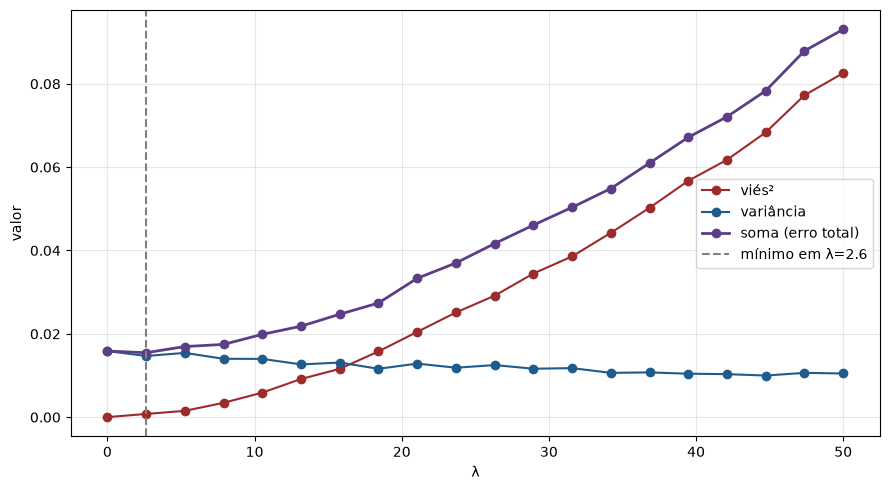

In [7]:
n, p = 150, 6
beta_real_ex3 = np.array([2.0, -1.0, 0.5, 0.0, 0.0, 1.5])


def ridge_do_zero(X, y, lam):
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)


def experimento(lam, repeticoes=200):
    estimativas = []
    for _ in range(repeticoes):
        X = StandardScaler().fit_transform(rng.normal(0, 1, (n, p)))
        y = X @ beta_real_ex3 + rng.normal(0, 1.5, n)
        estimativas.append(ridge_do_zero(X, y, lam) if lam > 0
                           else np.linalg.lstsq(X, y, rcond=None)[0])
    estimativas = np.array(estimativas)
    vies2 = np.mean((estimativas.mean(axis=0) - beta_real_ex3) ** 2)
    variancia = np.mean(estimativas.var(axis=0))
    return vies2, variancia


lambdas = np.linspace(0, 50, 20)
resultado = [experimento(lam) for lam in lambdas]
vies2s = [r[0] for r in resultado]
variancias = [r[1] for r in resultado]
somas = [v + var for v, var in zip(vies2s, variancias)]

lambda_otimo = lambdas[np.argmin(somas)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lambdas, vies2s, "o-", color=VERMELHO, label="viés²")
ax.plot(lambdas, variancias, "o-", color=AZUL, label="variância")
ax.plot(lambdas, somas, "o-", color=ROXO, lw=2, label="soma (erro total)")
ax.axvline(lambda_otimo, color="gray", ls="--", label=f"mínimo em λ={lambda_otimo:.1f}")
ax.set_xlabel("λ"); ax.set_ylabel("valor")
ax.legend(); plt.tight_layout(); plt.show()

---
## Exercício 4 🟡 — LassoCV vs. escolher alpha "no olho" contra o teste

Compare o RMSE de teste de: (a) `LassoCV` ajustado corretamente só no
treino, e (b) um alpha escolhido testando 30 valores diretamente contra o
`X_teste` e ficando com o melhor (o jeito ERRADO, mas comum). Ambos devem
ser avaliados numa terceira fatia de dados nunca tocada, para expor a
diferença.

In [8]:
# --- sua resposta ---

### Gabarito 4

In [9]:
# Uma única repetição é ruído demais para comparar as duas abordagens de
# forma confiável -- repetimos com vários datasets e splits independentes, e
# comparamos as MÉDIAS. É o mesmo motivo pelo qual o tema 1 nunca confia em
# n=1 para nada.
n, p, n_relevantes = 200, 60, 8
n_repeticoes = 40
alphas_grade = np.logspace(-3, 1, 30)

rmses_reportados_b, rmses_finais_a, rmses_finais_b = [], [], []
for rep in range(n_repeticoes):
    rng_rep = np.random.default_rng(1000 + rep)
    X = StandardScaler().fit_transform(rng_rep.normal(0, 1, (n, p)))
    beta_real = np.concatenate([rng_rep.normal(0, 1, n_relevantes),
                                np.zeros(p - n_relevantes)])
    y = X @ beta_real + rng_rep.normal(0, 1, n)

    X_treino, X_resto, y_treino, y_resto = train_test_split(
        X, y, test_size=0.5, random_state=rep)
    X_teste, X_val, y_teste, y_val = train_test_split(
        X_resto, y_resto, test_size=0.5, random_state=rep)

    # (a) CORRETO: LassoCV ajusta alpha usando validação cruzada DENTRO do treino
    modelo_correto = LassoCV(alphas=alphas_grade, max_iter=10000, random_state=0)
    modelo_correto.fit(X_treino, y_treino)
    rmses_finais_a.append(
        np.sqrt(mean_squared_error(y_val, modelo_correto.predict(X_val))))

    # (b) ERRADO: escolher alpha espiando o X_teste
    melhor_alpha, melhor_rmse_teste = None, np.inf
    for alpha in alphas_grade:
        modelo = Lasso(alpha=alpha, max_iter=10000).fit(X_treino, y_treino)
        rmse = np.sqrt(mean_squared_error(y_teste, modelo.predict(X_teste)))
        if rmse < melhor_rmse_teste:
            melhor_rmse_teste, melhor_alpha = rmse, alpha
    modelo_errado = Lasso(alpha=melhor_alpha, max_iter=10000).fit(X_treino, y_treino)
    rmses_reportados_b.append(melhor_rmse_teste)
    rmses_finais_b.append(
        np.sqrt(mean_squared_error(y_val, modelo_errado.predict(X_val))))

print(f"média de {n_repeticoes} repetições independentes:\n")
print(f"(b) RMSE REPORTADO no momento da escolha (espiando o teste): "
      f"{np.mean(rmses_reportados_b):.4f}")
print(f"(a) RMSE final honesto (LassoCV, nunca viu o teste)         : "
      f"{np.mean(rmses_finais_a):.4f}")
print(f"(b) RMSE final honesto (alpha escolhido espiando o teste)   : "
      f"{np.mean(rmses_finais_b):.4f}")

média de 40 repetições independentes:

(b) RMSE REPORTADO no momento da escolha (espiando o teste): 1.0953
(a) RMSE final honesto (LassoCV, nunca viu o teste)         : 1.1273
(b) RMSE final honesto (alpha escolhido espiando o teste)   : 1.1361


**Resposta esperada, agora estável na média:** o número que a abordagem
(b) "reporta" no momento da escolha é sistematicamente mais otimista do
que o RMSE real medido depois, numa fatia nunca usada para decidir nada —
a diferença entre essas duas linhas **é** o vazamento, quantificado. Numa
única repetição isolada essa diferença pode sumir ou até inverter por puro
ruído amostral (como você teria visto rodando este experimento uma vez só)
— é exatamente por isso que a conclusão certa vem da média de várias
repetições, não de uma rodada.

---
## Exercício 5 🔴 — Simulando o cenário "p > n" e comparando os três

Gere um dataset com $n=60$ observações e $p=100$ features, das quais só 5
têm efeito real. Compare Ridge, Lasso e Elastic Net na capacidade de
recuperar quais features são as 5 verdadeiras (via os coeficientes de maior
magnitude) e no RMSE de um conjunto de teste separado.

In [10]:
# --- sua resposta ---

### Gabarito 5

In [11]:
from sklearn.linear_model import ElasticNetCV

n, p = 60, 100
X = StandardScaler().fit_transform(rng.normal(0, 1, (n, p)))
indices_reais = rng.choice(p, 5, replace=False)
beta_real = np.zeros(p)
beta_real[indices_reais] = rng.uniform(1.5, 3.0, 5) * rng.choice([-1, 1], 5)
y = X @ beta_real + rng.normal(0, 1, n)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=0)

modelos_p_maior_n = {
    "Ridge": RidgeCV(alphas=np.logspace(-2, 3, 30)),
    "Lasso": LassoCV(alphas=np.logspace(-2, 1, 30), max_iter=10000, random_state=0),
    "Elastic Net": ElasticNetCV(alphas=np.logspace(-2, 1, 30), l1_ratio=0.5,
                                max_iter=10000, random_state=0),
}

print(f"features verdadeiramente relevantes: {sorted(indices_reais)}\n")
for nome, modelo in modelos_p_maior_n.items():
    modelo.fit(X_treino, y_treino)
    rmse = np.sqrt(mean_squared_error(y_teste, modelo.predict(X_teste)))
    top5_encontradas = np.argsort(np.abs(modelo.coef_))[-5:]
    acerto = len(set(top5_encontradas) & set(indices_reais))
    print(f"{nome:<14s} RMSE={rmse:.4f}   "
          f"top-5 por |coef| acerta {acerto}/5 das features reais   "
          f"nº não-zero={np.sum(np.abs(modelo.coef_) > 1e-6)}/{p}")

features verdadeiramente relevantes: [np.int64(10), np.int64(39), np.int64(57), np.int64(69), np.int64(93)]

Ridge          RMSE=3.4815   top-5 por |coef| acerta 3/5 das features reais   nº não-zero=100/100
Lasso          RMSE=1.3118   top-5 por |coef| acerta 5/5 das features reais   nº não-zero=35/100
Elastic Net    RMSE=2.2473   top-5 por |coef| acerta 4/5 das features reais   nº não-zero=47/100


**Resposta esperada:** com $p > n$, mínimos quadrados comum nem teria
solução única — este é o regime onde regularização deixa de ser
"recomendável" e passa a ser **necessária**. Lasso e Elastic Net devem
recuperar as features reais com mais precisão que Ridge (que nunca zera
nada e mantém sinal espalhado por todas as 100 features), porque a
esparsidade real do problema (só 5 de 100 importam) favorece exatamente o
tipo de solução que a penalidade L1 produz.

---
## Fechamento

- Padronizar antes de regularizar não é opcional — sem isso, a penalidade
  pune a escala das unidades, não a importância real da feature.
- O lambda que minimiza o erro total quase nunca é zero — o trade-off
  viés-variância é mensurável, não só teórico.
- Escolher hiperparâmetro espiando o conjunto de teste infla o desempenho
  relatado — o mesmo princípio de vazamento do tema 3, aplicado a
  hiperparâmetros.
- Em problemas com muitas features e esparsidade real (especialmente
  $p > n$), Lasso e Elastic Net têm vantagem estrutural sobre Ridge.

→ Próximo módulo: **Regressão Logística**, o primeiro modelo de
classificação do tema.